In [73]:
# P1.0 导入库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
%matplotlib inline

In [75]:
# P1.1读入训练集
df_train = pd.read_csv('./dataset/train.csv')
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [77]:
# P1.2 SalePrice的统计特征
df_train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [79]:
# P1.3 ?????
sns.histplot(df_train['SalePrice'], kde=True);

In [80]:
# P1.3 偏度和峰度
print('偏度: {:.2f}'.format(df_train['SalePrice'].skew()))
print('峰度: {:.2f}'.format(df_train['SalePrice'].kurt()))

偏度: 1.88
峰度: 6.54


In [82]:
# P1.4 GrLivArea 与 SalePrice关系
var = 'GrLivArea'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000));

In [85]:
# P1.4 TotalBsmtSF 与 SalePrice 关系
var = 'TotalBsmtSF'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000));

In [87]:
# P1.4 OverallQual 与 SalePrice关系
var = 'OverallQual'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
f, ax = plt.subplots(figsize=(8, 5))
fig = sns.boxplot(x=var, y="SalePrice", data=data)
fig.axis(ymin=0, ymax=800000);

In [88]:
# P1.4 YearBuilt与SalePrice关系
var = 'YearBuilt'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
f, ax = plt.subplots(figsize=(20, 8))
fig = sns.boxplot(x=var, y="SalePrice", data=data)
fig.axis(ymin=0, ymax=800000);
plt.xticks(rotation=90);

In [90]:
# P1.4 相关矩阵
corrmat = df_train.select_dtypes(include=[np.number]).corr()
mask = np.zeros_like(corrmat, dtype=bool)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(corrmat, mask=mask, cmap="coolwarm", center=0,
            square=True, linewidths=.2, cbar_kws={"shrink":.8});

In [94]:
# P1.4 最相关矩阵
k = 10 # 只显示十组变量
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(df_train[cols].values.T)
mask = np.zeros_like(cm, dtype=bool)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap="coolwarm", 
            vmax=1, vmin=-1, square=True, linewidths=.2, annot_kws={'size': 12}, 
            yticklabels=cols.values, xticklabels=cols.values);

In [97]:
# P1.5 缺失数据统计
total = df_train.isnull().sum().sort_values(ascending=False)
percent = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data[missing_data.Total>0]

,Total,Percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageYrBlt,81,0.055479
GarageCond,81,0.055479
GarageType,81,0.055479


In [99]:
# P1.5 缺失数据清洗
df_train = df_train.drop((missing_data[missing_data['Total'] > 1]).index, axis=1)
df_train = df_train.drop(df_train.loc[df_train['Electrical'].isnull()].index)
print(df_train.isnull().sum().max()) # 重新统计缺失数据
print(df_train.shape)

0
(1459, 63)


In [101]:
# P1.6 删除GrLivArea离群值
df_train.sort_values(by = 'GrLivArea', ascending = False)[:2]
df_train = df_train.drop(df_train[df_train['Id'] == 1299].index)
df_train = df_train.drop(df_train[df_train['Id'] == 524].index)

In [103]:
# P1.6 删除TotalBsmtSF离群值
df_train.sort_values(by = 'TotalBsmtSF', ascending = False)[:1]
df_train = df_train.drop(df_train[df_train['Id'] == 333].index)
print(df_train.shape)
df_train_copy = df_train.copy()

(1456, 63)


In [105]:
# P1.7 绘制SalePrice的直方图与概率图
sns.histplot(df_train['SalePrice'], kde=True);
fig = plt.figure()
res = stats.probplot(df_train['SalePrice'], plot=plt)

In [106]:
# P1.7 对数变换
df_train['SalePrice'] = np.log1p(df_train['SalePrice'])
# 绘制调整后的直方图与概率图
sns.histplot(df_train['SalePrice'], kde=True);
fig = plt.figure()
res = stats.probplot(df_train['SalePrice'], plot=plt)

In [108]:
# P1.7  GrLivArea直方图与概率图
sns.histplot(df_train['GrLivArea'], kde=True);
fig = plt.figure()
res = stats.probplot(df_train['GrLivArea'], plot=plt)

In [110]:
# P1.7  GrLivArea对数变换
df_train['GrLivArea'] = np.log1p(df_train['GrLivArea'])
# GrLivArea对数变换后的直方图与概率图
sns.histplot(df_train['GrLivArea'], kde=True);
fig = plt.figure()
res = stats.probplot(df_train['GrLivArea'], plot=plt)

In [112]:
# P1.7  TotalBsmtSF 的直方图与概率图
sns.histplot(df_train['TotalBsmtSF'], kde=True);
fig = plt.figure()
res = stats.probplot(df_train['TotalBsmtSF'], plot=plt)

In [114]:
# P1.8 GrLivArea 与 SalePrice 的残差图
# 对数变换前，GrLivArea 与 SalePrice 的残差图
plt.subplots(figsize = (6,5))
sns.residplot(x=df_train_copy.GrLivArea, y=df_train_copy.SalePrice);
# 对数变换后，GrLivArea 与 SalePrice 的残差图
plt.subplots(figsize = (6,5))
sns.residplot(x=df_train.GrLivArea, y=df_train.SalePrice);

In [117]:
# P1.9 手工计算 beta 系数值 
sample_train=df_train.copy()
y_avg = sample_train.SalePrice.mean()
x_avg = sample_train.GrLivArea.mean()
std_y = sample_train.SalePrice.std()
std_x = sample_train.GrLivArea.std()
r_xy = sample_train.select_dtypes(include=[np.number]).corr().loc['GrLivArea','SalePrice']
beta_1 = r_xy*(std_y/std_x)
beta_0 = y_avg - beta_1*x_avg

In [119]:
# P1.10 计算预测值 y_hat 
sample_train['Yhat'] = beta_0 + beta_1*sample_train['GrLivArea']
sample_train[['SalePrice','Yhat']].head() 

,SalePrice,Yhat
0,12.247699,12.182637
1,12.109016,11.911687
2,12.317171,12.221425
3,11.849405,12.186281
4,12.429220,12.406586


In [123]:
# P1.10 绘制回归直线图
fig = plt.figure(figsize=(8,5))
ax = plt.gca()
ax.scatter(sample_train.GrLivArea, sample_train.SalePrice, c='b')
ax.plot(sample_train['GrLivArea'], sample_train['Yhat'], color='r');

In [125]:
# P1.22 均方误差(MSE)，计算方法1
print("均方误差(MSE) : {}".
      format(np.square(sample_train['SalePrice'] - sample_train['Yhat']).mean()))

均方误差(MSE) : 0.07281647980414087


In [127]:
# P1.10 均方误差(MSE)，计算方法2
from sklearn.metrics import mean_squared_error
mean_squared_error(sample_train['SalePrice'], sample_train.Yhat)

0.07281647980414087

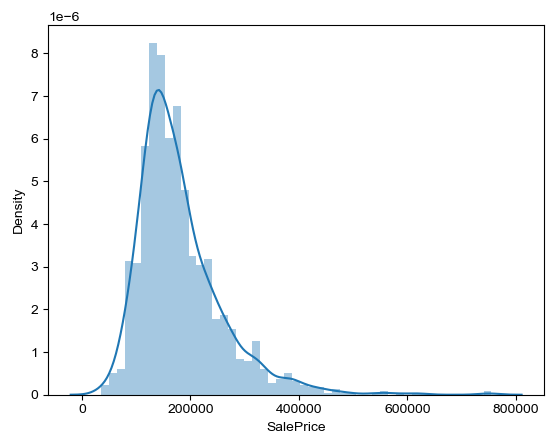

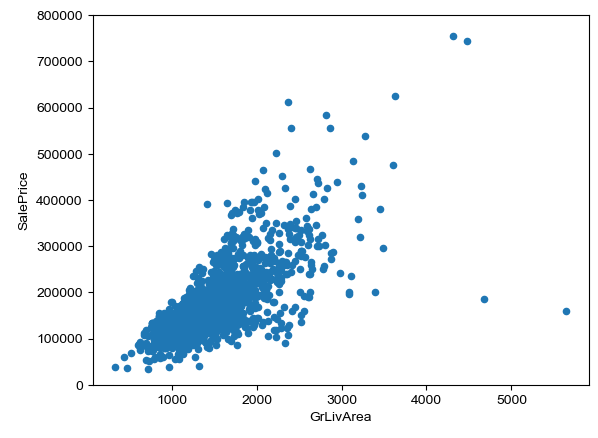

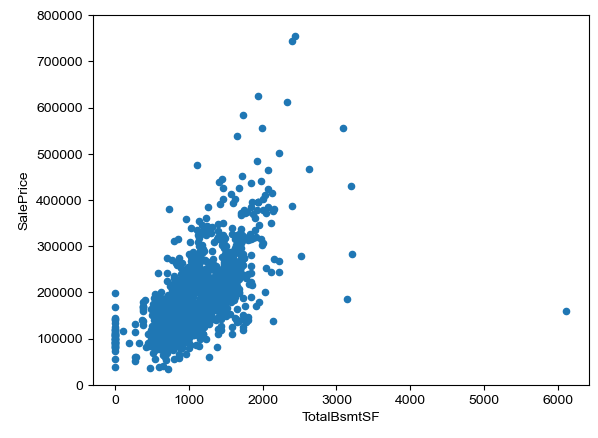

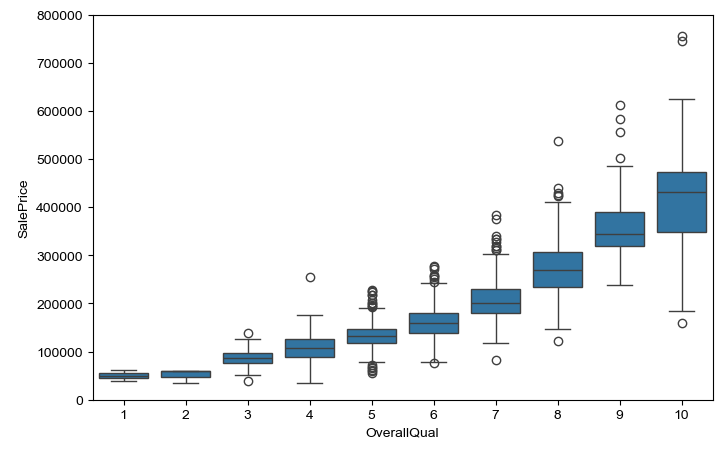

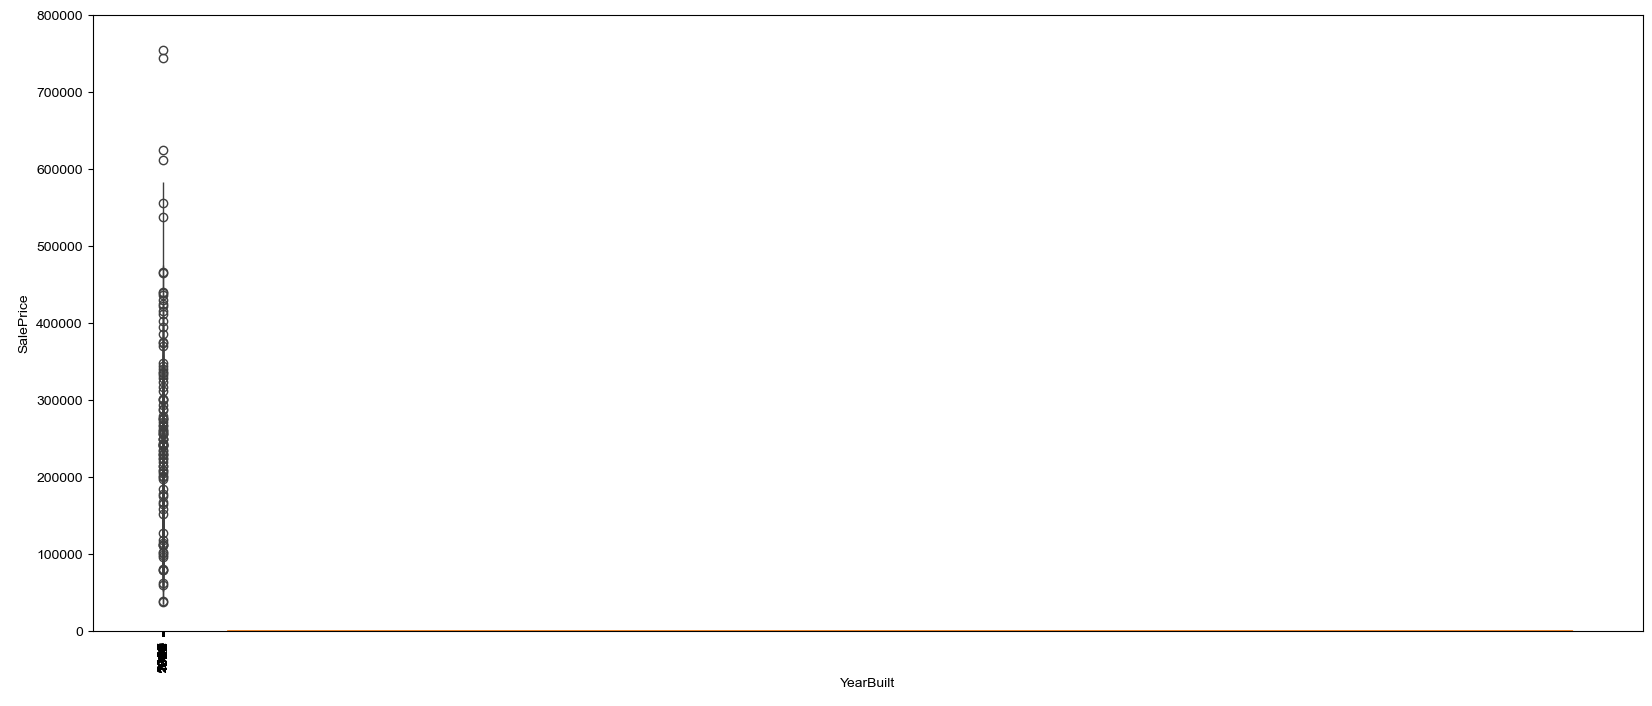

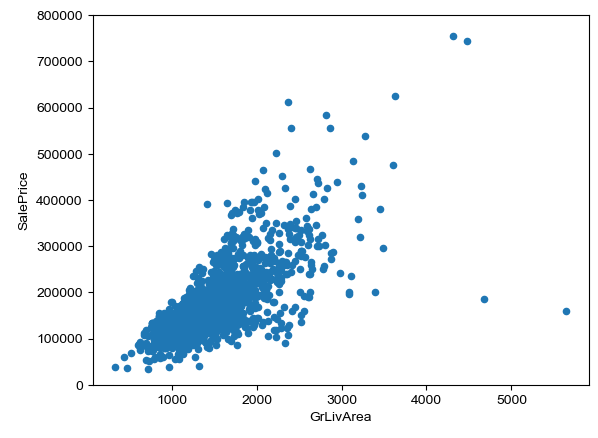

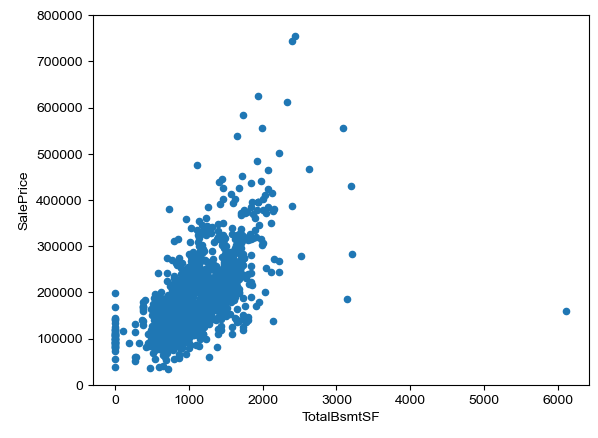

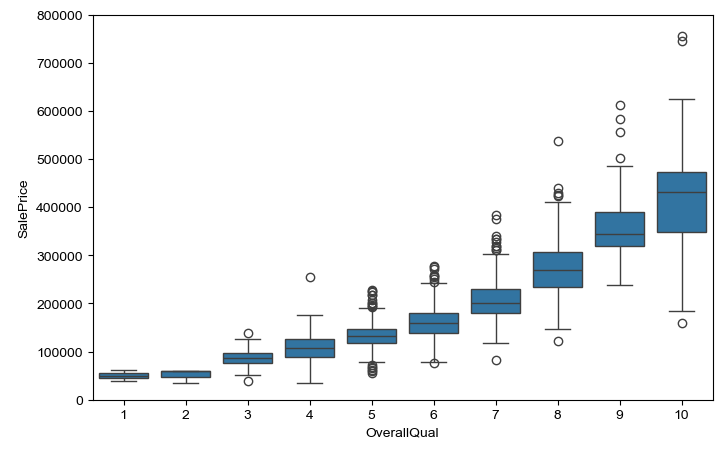

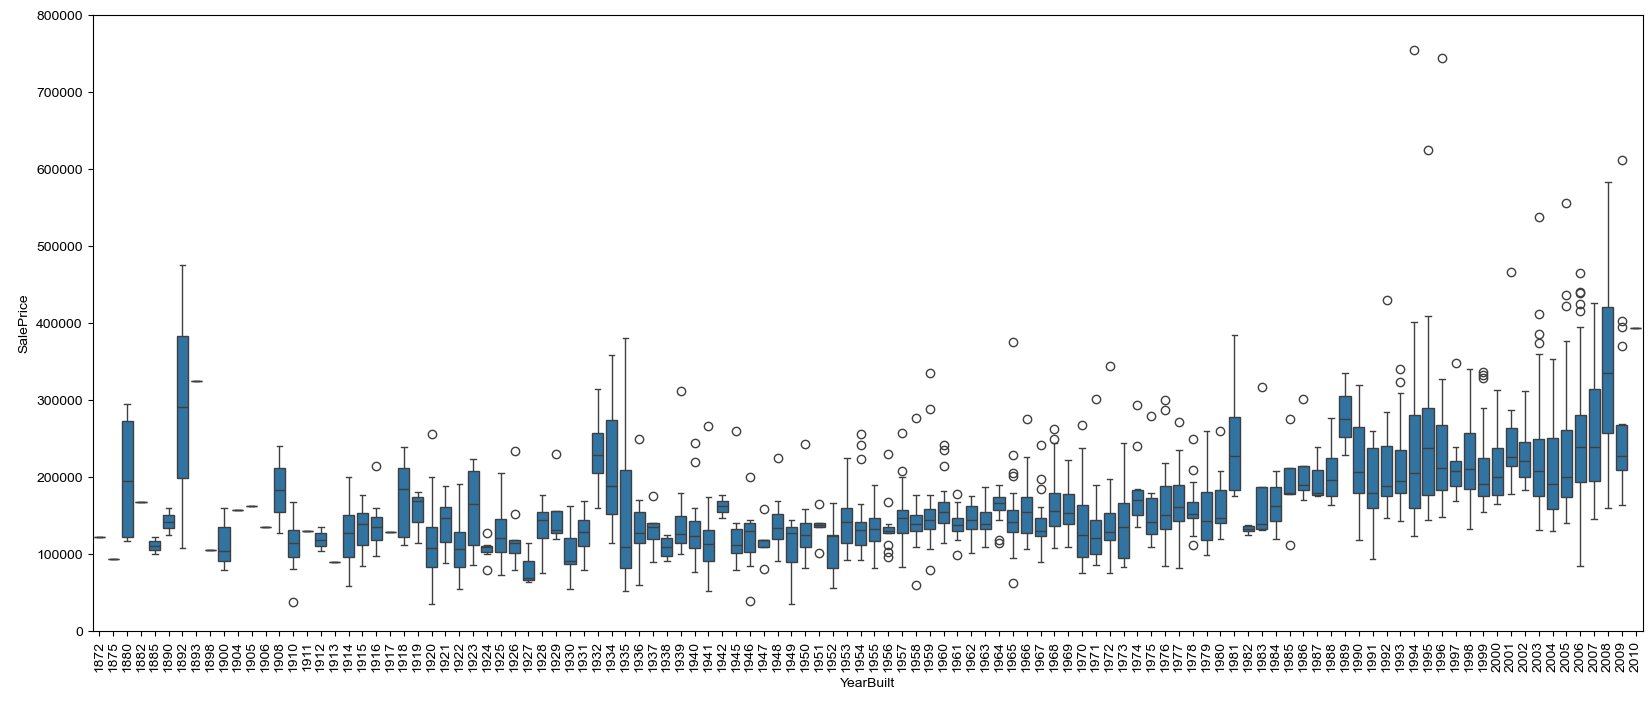

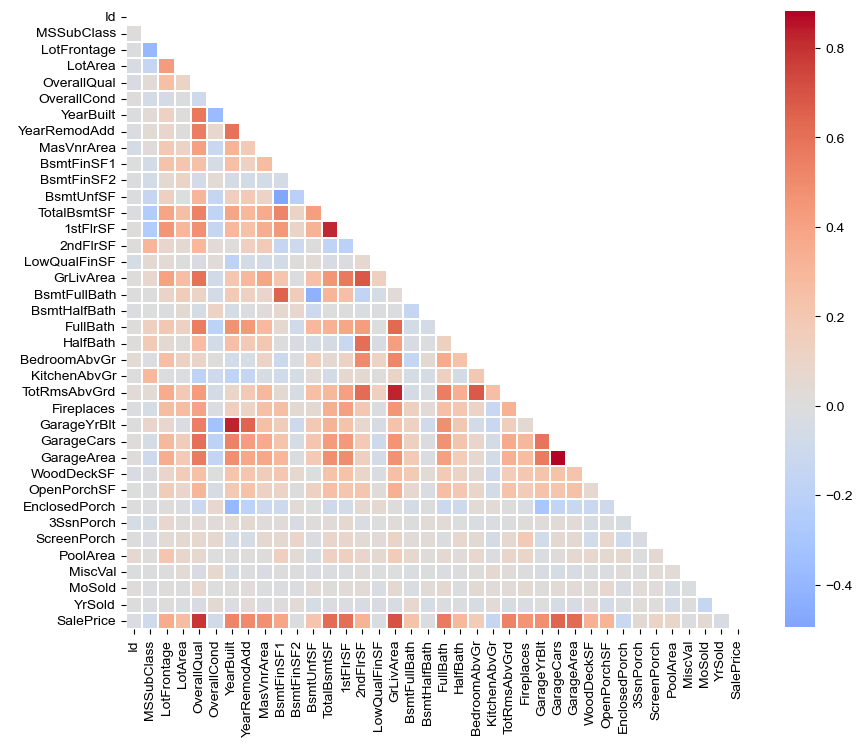

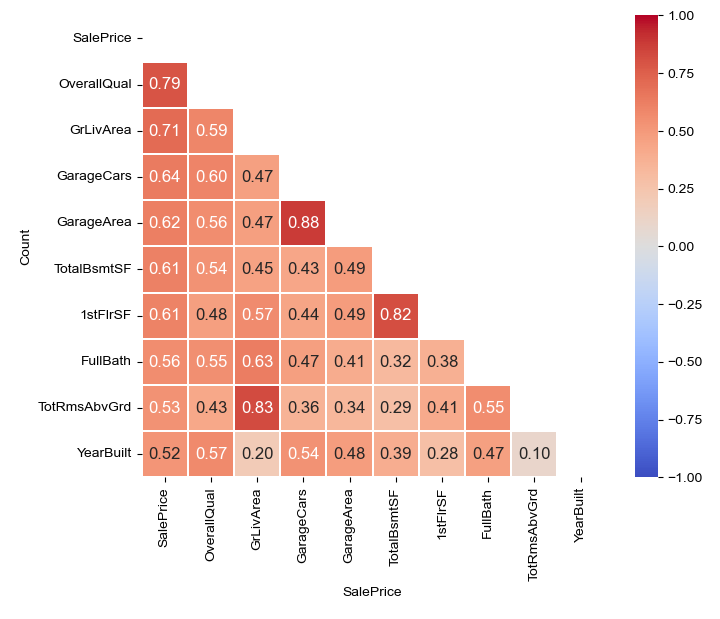

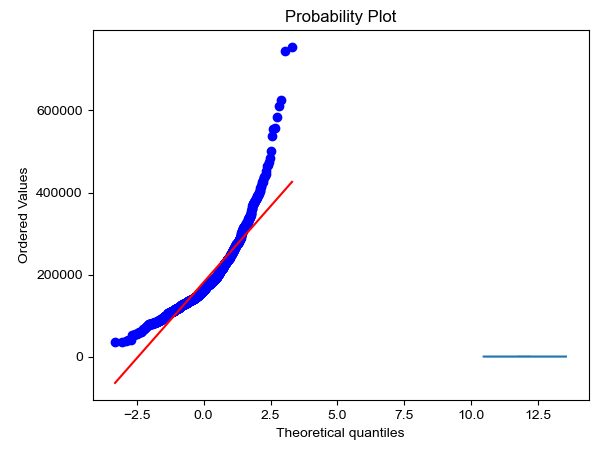

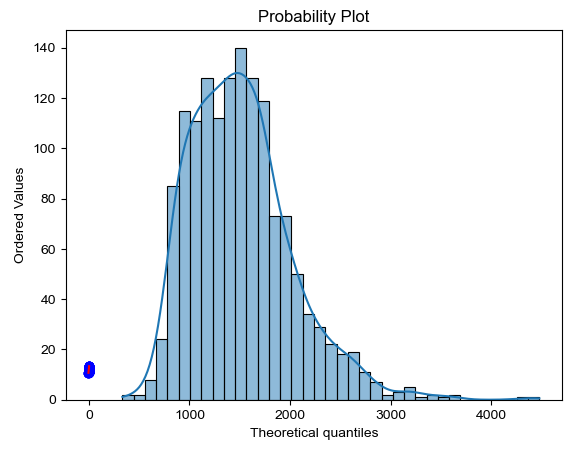

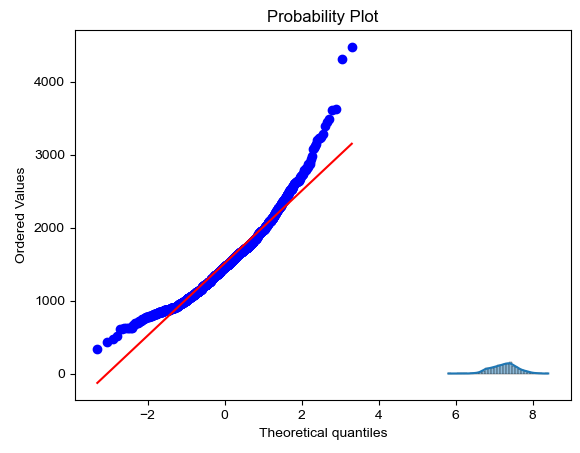

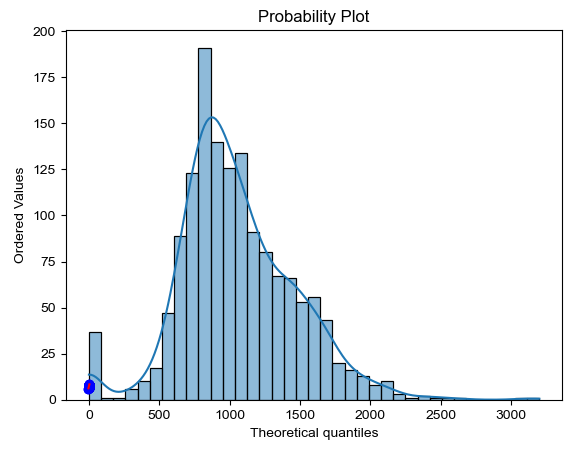

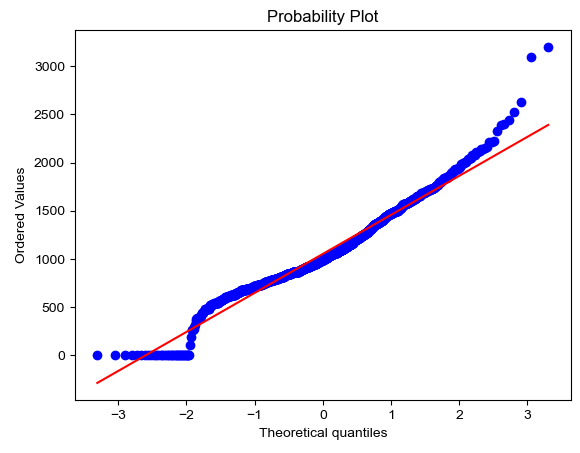

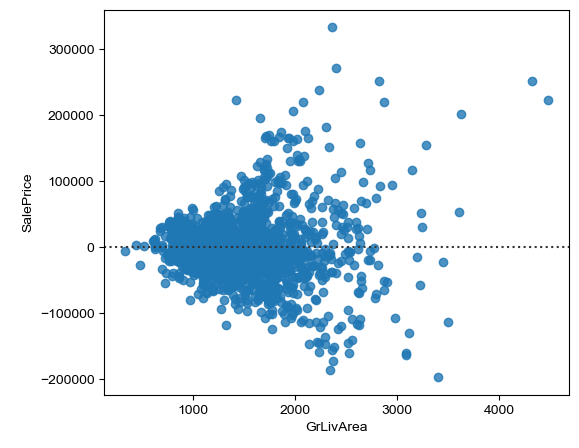

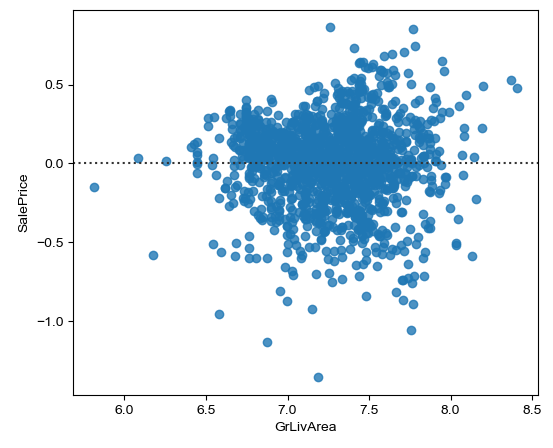

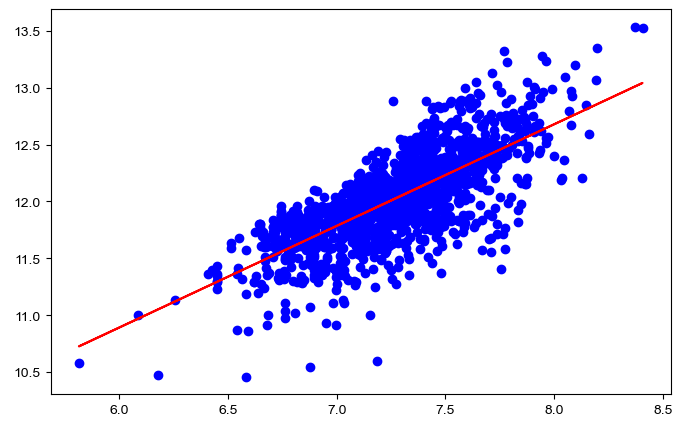

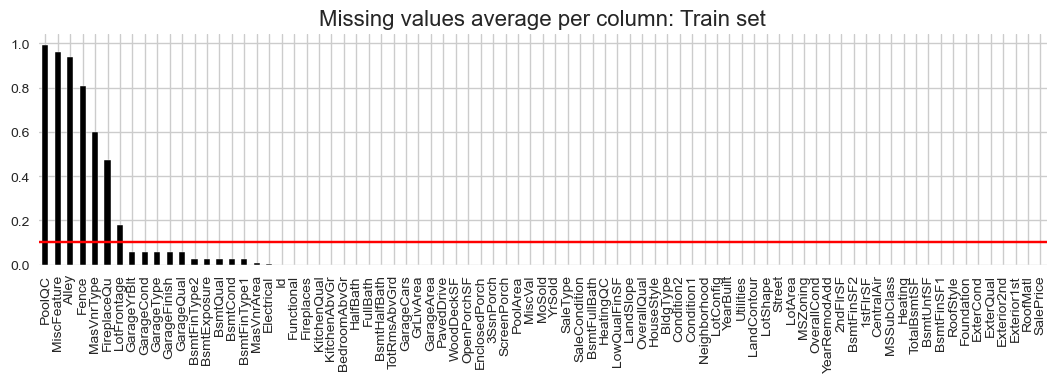

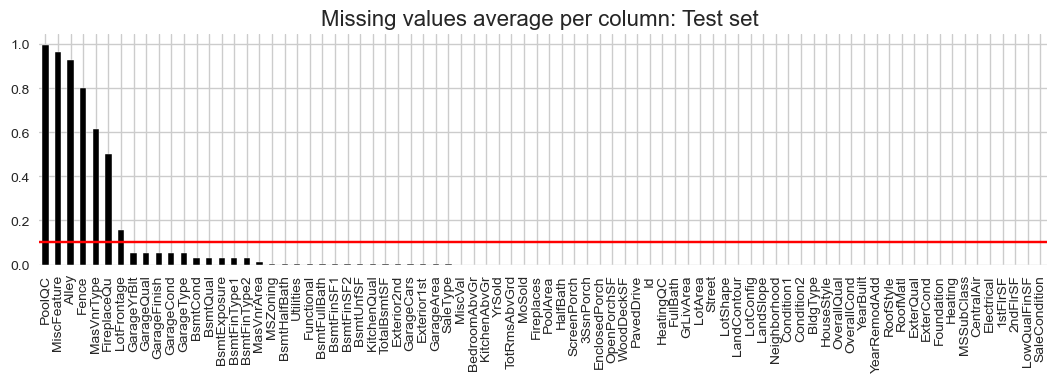

In [129]:
# P1.12 读入数据集，绘图观察缺失数据
train = pd.read_csv('./dataset/train.csv')
test=pd.read_csv('./dataset/test.csv')
plt.style.use('seaborn-v0_8')
sns.set_style('whitegrid')
plt.figure(figsize=(13,3))
train.isnull().mean().sort_values(ascending=False).plot.bar(color='black')
plt.axhline(y=0.1, color='r', linestyle='-')
plt.title('Missing values average per column: Train set', fontsize=16)
plt.show()
plt.figure(figsize=(13,3))
test.isnull().mean().sort_values(ascending=False).plot.bar(color='black')
plt.axhline(y=0.1, color='r', linestyle='-')
plt.title('Missing values average per column: Test set ', fontsize=16)
plt.show()


In [130]:
# P1.12 合并训练集与测试集
rows_train = train.shape[0]
rows_test = test.shape[0]
train_label = train['SalePrice'].to_frame()
combined = pd.concat((train, test), sort=False).reset_index(drop=True)
combined.drop(['SalePrice'], axis=1, inplace=True)
combined.drop(['Id'], axis=1, inplace=True)
print("合并后的数据集维度 :",combined.shape)

合并后的数据集维度 : (2919, 79)


从合并集中删除了 7 个特征


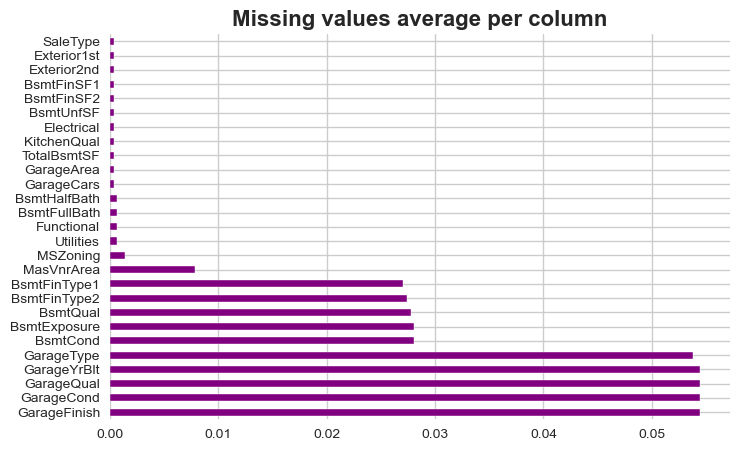

In [132]:
# P1.12	清除缺失率超过15%的特征，绘图显示其他特征缺失率
combined2 = combined.dropna(thresh=len(combined) * 0.85, axis=1).copy()
print('从合并集中删除了',combined.shape[1]-combined2.shape[1], '个特征')
allna = (combined2.isnull().sum() / len(combined2))
allna = allna.drop(allna[allna == 0].index).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
allna.plot.barh(color='purple')
plt.title('Missing values average per column', fontsize=16, weight='bold' )
plt.show()

In [135]:
# P1.12 ??????????
missing_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageYrBlt',
      'BsmtFinType2', 'BsmtFinType1', 'BsmtCond', 'BsmtQual', 'BsmtExposure', 'MasVnrArea', 'MasVnrType',
      'Electrical', 'MSZoning', 'BsmtFullBath', 'BsmtHalfBath', 'Utilities', 'Functional', 'Exterior1st', 'BsmtUnfSF',
      'Exterior2nd', 'TotalBsmtSF', 'GarageArea', 'GarageCars', 'KitchenQual', 'BsmtFinSF2', 'BsmtFinSF1', 'SaleType']
available_missing_cols = [col for col in missing_cols if col in combined2.columns]
Missing = combined2[available_missing_cols]
Missing_cat = Missing.select_dtypes(include='object')
Missing_num = Missing.select_dtypes(exclude='object')
print('?? :', Missing_cat.shape[1], '?????????')
print('?? :', Missing_num.shape[1], '?????????')


?? : 17 ?????????
?? : 10 ?????????


In [136]:
Missing_num.head()

,GarageYrBlt,MasVnrArea,BsmtFullBath,BsmtHalfBath,BsmtUnfSF,TotalBsmtSF,GarageArea,GarageCars,BsmtFinSF2,BsmtFinSF1
0,2003.0,196.0,1.0,0.0,150.0,856.0,548.0,2.0,0.0,706.0
1,1976.0,0.0,0.0,1.0,284.0,1262.0,460.0,2.0,0.0,978.0
2,2001.0,162.0,1.0,0.0,434.0,920.0,608.0,2.0,0.0,486.0
3,1998.0,0.0,1.0,0.0,540.0,756.0,642.0,3.0,0.0,216.0
4,2000.0,350.0,1.0,0.0,490.0,1145.0,836.0,3.0,0.0,655.0


In [138]:
Missing_cat.head()

,GarageType,GarageFinish,GarageQual,GarageCond,BsmtFinType2,BsmtFinType1,BsmtCond,BsmtQual,BsmtExposure,Electrical,MSZoning,Utilities,Functional,Exterior1st,Exterior2nd,KitchenQual,SaleType
0,Attchd,RFn,TA,TA,Unf,GLQ,TA,Gd,No,SBrkr,RL,AllPub,Typ,VinylSd,VinylSd,Gd,WD
1,Attchd,RFn,TA,TA,Unf,ALQ,TA,Gd,Gd,SBrkr,RL,AllPub,Typ,MetalSd,MetalSd,TA,WD
2,Attchd,RFn,TA,TA,Unf,GLQ,TA,Gd,Mn,SBrkr,RL,AllPub,Typ,VinylSd,VinylSd,Gd,WD
3,Detchd,Unf,TA,TA,Unf,ALQ,Gd,TA,No,SBrkr,RL,AllPub,Typ,Wd Sdng,Wd Shng,Gd,WD
4,Attchd,RFn,TA,TA,Unf,GLQ,TA,Gd,Av,SBrkr,RL,AllPub,Typ,VinylSd,VinylSd,Gd,WD


In [139]:
Missing_cat1= Missing_cat.isnull().sum().to_frame().sort_values(by=[0])
Missing_cat1

,0
SaleType,1
Exterior2nd,1
Exterior1st,1
KitchenQual,1
Electrical,1
Functional,2
Utilities,2
MSZoning,4
BsmtFinType1,79
BsmtFinType2,80


In [141]:
#P1.12 ??????
if 'GarageYrBlt' in combined2.columns:
    combined2['GarageYrBlt'] = combined2['GarageYrBlt'].fillna(1980)
# ??????????????????????????8?????????4
for col in ['Electrical', 'SaleType', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'Functional', 'Utilities', 'MSZoning']:
    if col in combined2.columns:
        combined2[col] = combined2[col].ffill()
# ???????????????????100???????? None ??
all_cols = combined2.columns
for col in all_cols:
    if combined2[col].dtype == 'object':
        combined2[col] = combined2[col].fillna('None')
# ?? GarageYrBlt ???????????? 0
for col in all_cols:
    if combined2[col].dtype != 'object':
        combined2[col] = combined2[col].fillna(0)
combined2.isnull().sum().sort_values(ascending=False).head()


MSSubClass      0
MSZoning        0
Fireplaces      0
Functional      0
TotRmsAbvGrd    0
dtype: int64

In [144]:
# P1.12 检查训练集相关性，找出高相关特征
corrmat = train.select_dtypes(include=[np.number]).corr()
k=corrmat.shape[0]
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = (pd.DataFrame(train[cols].values)).corr()
mask = np.zeros_like(cm, dtype=bool)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(cm,mask=mask,annot=True,fmt='.1f',cmap="coolwarm",vmax=1,vmin=-1,square=True,
            linewidths=.2,annot_kws={'size': 9},yticklabels=cols.values,xticklabels=cols.values)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
for i in range(0,k):
    for j in range(0,k):
        if (cm[i][j]>0.8 and i < j):
            print(cols[i] + '与'+ cols[j]+'相关性 ={:.2f}'.format(cm[i][j]))

GrLivArea与TotRmsAbvGrd相关性 =0.83
GarageCars与GarageArea相关性 =0.88
TotalBsmtSF与1stFlrSF相关性 =0.82
YearBuilt与GarageYrBlt相关性 =0.83


In [147]:
# P1.12 ?????????????????85%?
combined3 = combined2.drop(['TotRmsAbvGrd', 'GarageCars', '1stFlrSF', 'GarageYrBlt'], axis=1, errors='ignore')
drop_col = []
# ??????????
max_ratio = combined3.apply(lambda x: x.value_counts().max() / len(x) if len(x.value_counts()) > 0 else 0)
# ???????85%??
drop_col = max_ratio[max_ratio > 0.85].index.tolist()

# ????
for col in drop_col:
    print('{0} , {1:.4f}'.format(col, max_ratio[col]))

combined3 = combined3.drop(drop_col, axis=1)
print(combined3.shape)


Street , 0.9959
LandContour , 0.8983
Utilities , 0.9997
LandSlope , 0.9517
Condition1 , 0.8602
Condition2 , 0.9897
RoofMatl , 0.9853
ExterCond , 0.8695
BsmtCond , 0.8928
BsmtFinType2 , 0.8541
BsmtFinSF2 , 0.8811
Heating , 0.9846
CentralAir , 0.9329
Electrical , 0.9154
LowQualFinSF , 0.9863
BsmtHalfBath , 0.9400
KitchenAbvGr , 0.9541
Functional , 0.9315
GarageQual , 0.8921
GarageCond , 0.9092
PavedDrive , 0.9048
3SsnPorch , 0.9873
ScreenPorch , 0.9123
PoolArea , 0.9955
MiscVal , 0.9647
SaleType , 0.8654
(2919, 42)


In [150]:
# P1.12 数值型转类别型
combined3[['MoSold','MSSubClass','YrSold']]= combined3[['MoSold','MSSubClass','YrSold']].astype(str)

In [152]:
# P1.12 One-Hot 编码
combined_new=pd.get_dummies(combined3)
print("数据集编码前的维度：",combined3.shape)
print("数据集编码后的维度：",combined_new.shape)
print("数据集新增了 ",combined_new.shape[1]- combined3.shape[1], '个编码特征')

数据集编码前的维度： (2919, 42)
数据集编码后的维度： (2919, 195)
数据集新增了  153 个编码特征


In [154]:
# P1.12 对数变换，正态分布调整
cols = ['GrLivArea','TotalBsmtSF','GarageArea','LotArea',
        'YearBuilt','YearRemodAdd','BsmtFinSF1','BsmtUnfSF']
for col in cols:
    combined_new[col] = np.log1p(combined_new[col])
train_label['SalePrice'] = np.log1p(train_label['SalePrice'])

In [159]:
# P1.13 合并集拆分为训练集与测试集
train = combined_new[:rows_train] 
test = combined_new[rows_train:] 
print(train.shape)
print(test.shape)
print(train_label.shape)

(1460, 195)
(1459, 195)
(1460, 1)


In [167]:
# P1.13 训练集进一步划分为训练与验证两部分
from sklearn.model_selection import train_test_split
x=train
y=np.array(train_label)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = .33, random_state=0)

In [169]:
# P1.13 标准化训练集、验证集与测试集
from sklearn.preprocessing import RobustScaler
scaler= RobustScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
X_train= scaler.transform(train)
X_test= scaler.transform(test)

In [170]:
# P1.14 线性回归模型
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error, r2_score
import math
model_result = []
lr_mod = LinearRegression().fit(x_train, y_train)
y_train_pred = lr_mod.predict(x_train)
y_val_pred = lr_mod.predict(x_val)
RMSE_train = math.sqrt(mean_squared_error(y_train, y_train_pred))
RMSE_val = math.sqrt(mean_squared_error(y_val, y_val_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)
lr_mod_result = {'RMSE_train':RMSE_train, 'RMSE_val':RMSE_val, 'r2_train':r2_train, 'r2_val':r2_val}
print("训练集均方根误差：{0:.2f}，训练集决定系数：{1:.2f}".format(round(RMSE_train,2),round(r2_train,2)))
print("验证集均方根误差：{0:.2f}，验证集决定系数：{1:.2f}".format(round(RMSE_val,2),round(r2_val,2)))

训练集均方根误差：0.10，训练集决定系数：0.93
验证集均方根误差：0.14，验证集决定系数：0.86
